# 03 — Evaluación del sistema GraphRAG (metodología RAGAS)

Este notebook evalúa el pipeline GraphRAG sobre Sherlock Holmes usando las tres métricas 
**RAGAS**. El enfoque **no** requiere la librería RAGAS — todas las métricas se implementan 
como llamadas estructuradas al LLM.

### Las tres métricas

| Métrica | Qué mide | Cómo |
|---|---|---|
| **context_recall** | ¿El recuperador obtuvo chunks que cubren la verdad esperada? | Cada frase del ground truth se verifica: ¿puede atribuirse al contexto recuperado? |
| **faithfulness** | ¿La respuesta contiene solo cosas respaldadas por el contexto? | La respuesta se descompone en afirmaciones atómicas; cada una se verifica contra el contexto. |
| **answer_correctness** | ¿Cuánto se superpone la respuesta con el ground truth? | Las afirmaciones se clasifican en TP / FP / FN; se calcula el F1. |

### El pipeline de evaluación

```
CSV de benchmark
  (question ; cypher)
        │
        ▼
  load_dataset()       ← lee el CSV
        │
        ▼
  run_benchmark()      ← ejecuta Cypher para obtener ground truths dinámicos,
                         llama al agente RAG, registra latencia
        │
        ▼
  evaluate_results()   ← puntúa cada fila con las tres métricas RAGAS
        │
        ▼
  print_summary()      ← tabla agregada
```

**Requisito previo:** Ejecutar `01_ingestion_demo.ipynb` para cargar los datos de Sherlock Holmes en Neo4j.

## 1. Configuración

In [35]:
import sys
sys.path.append('..')

import pandas as pd
from graphrag.graph.neo4j_manager import Neo4jManager
from graphrag.agents import AgenticRAG
from graphrag.evaluation import RAGEvaluator

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

In [36]:
neo4j = Neo4jManager()
rag = AgenticRAG(neo4j)
evaluator = RAGEvaluator(rag, neo4j)
print("Sistema listo.")
print(f"Estado del grafo: {neo4j.get_stats()}")

Sistema listo.
Estado del grafo: {'Event': 412, 'Deduction': 323, 'Object': 269, 'Chunk': 200, 'Scene': 185, 'Location': 85, 'Character': 73, 'Crime': 19, 'Story': 6}


## 2. Inspección de métricas — pregunta a pregunta

Antes de ejecutar el benchmark completo, es instructivo ver qué hace cada métrica
internamente. Tomamos una sola pregunta y llamamos a cada métrica de forma manual.

In [37]:
question     = "Who does Holmes know?"
ground_truth = "Holmes knows Watson, Irene Adler, and Professor Moriarty, among other characters from the stories."

# Preguntamos al agente
answer, context = evaluator.get_answer(question)
print(f"Respuesta       : {answer}")
print(f"Chunks recuperados: {len(context)}")

Respuesta       : Holmes knows Abe Slaney [1], Colonel [2], Count Von Kramm [3], Dawson [4], Gregory [5], Irene Adler [6], Jabez Wilson [7], John Clay [8], Master Silas Brown [9], Miss Roylott [10], Mr. Merryweather [11], Mrs. Farintosh [12], Mrs. Hudson [13], Mrs. King [14], Mrs. Straker [15], Mrs. Watson [16], Mycroft [17], Peter Jones [18], Watson [19], Wilhelm Gottsreich Sigismond von Ormstein, Grand Duke of Cassel-Felstein, and hereditary King of Bohemia [20], and Wilson Hargreave [21].
Chunks recuperados: 21


In [38]:
# --- context_recall ---
# Objetivo: ¿puede atribuirse cada frase del ground truth al contexto recuperado?
# Puntuación = (frases atribuidas) / (total de frases)  →  rango [0, 1]
recall_result = evaluator.evaluate_context_recall(question, ground_truth, context, verbose=True)

print("context_recall")
print(f"  puntuación : {recall_result.get('recall', 0):.3f}")
print(f"  frases     : {recall_result.get('sentences', [])}")
print(f"  atribuidas : {recall_result.get('attributions', [])}")


── context_recall ──────────────────────────────────
  Question    : Who does Holmes know?
  Ground truth: Holmes knows Watson, Irene Adler, and Professor Moriarty, among other characters from the stories.
  Context chunks retrieved: 21

  [Step 1] Asking the LLM to attribute each ground-truth sentence to context...

  Ground-truth sentences (2):
    [✓ attributed] character_known_by_holmes: Watson; occupation: doctor
    [✓ attributed] character_known_by_holmes: Irene Adler; occupation: 

  Reasoning : The ground truth states that Holmes knows Watson, Irene Adler, and Professor Moriarty. The context explicitly lists Watson and Irene Adler as characters known by Holmes. However, Professor Moriarty is not mentioned anywhere in the provided context. Therefore, only two out of three specific individuals mentioned in the ground truth are supported by the context, leading to a recall score of 0.66 (2/3).
  Score     : 1.000
────────────────────────────────────────────────────
context_recal

In [39]:
# --- faithfulness ---
# Paso 1: descomponer la respuesta en afirmaciones atómicas sin pronombres.
# Paso 2: verificar si cada afirmación puede inferirse del contexto.
# Puntuación = (afirmaciones respaldadas) / (total)  →  rango [0, 1]
faith_result = evaluator.evaluate_faithfulness(question, answer, context, verbose=True)

print("faithfulness")
print(f"  puntuación  : {faith_result.get('faithfulness', 0):.3f}")
print(f"  afirmaciones: {faith_result.get('statements', [])}")
print(f"  veredictos  : {faith_result.get('verdicts', [])}")


── faithfulness ────────────────────────────────────
  Question: Who does Holmes know?
  Answer  : Holmes knows Abe Slaney [1], Colonel [2], Count Von Kramm [3], Dawson [4], Gregory [5], Irene Adler [6], Jabez Wilson [7], John Clay [8], Master Silas Brown [9], Miss Roylott [10], Mr. Merryweather [11], Mrs. Farintosh [12], Mrs. Hudson [13], Mrs. King [14], Mrs. Straker [15], Mrs. Watson [16], Mycroft [17], Peter Jones [18], Watson [19], Wilhelm Gottsreich Sigismond von Ormstein, Grand Duke of Cassel-Felstein, and hereditary King of Bohemia [20], and Wilson Hargreave [21].

  [Step 1] Decomposing the answer into statements...
  Statements extracted (21):
    1. Holmes knows Abe Slaney.
    2. Holmes knows Colonel.
    3. Holmes knows Count Von Kramm.
    4. Holmes knows Dawson.
    5. Holmes knows Gregory.
    6. Holmes knows Irene Adler.
    7. Holmes knows Jabez Wilson.
    8. Holmes knows John Clay.
    9. Holmes knows Master Silas Brown.
    10. Holmes knows Miss Roylott.
    11. Ho

In [40]:
# --- answer_correctness ---
# Objetivo: ¿cuánto se superpone la respuesta con el ground truth?
# Se clasifican afirmaciones en TP (correctas), FP (añadidas), FN (faltantes)
# Puntuación = F1-score  →  rango [0, 1]
corr_result = evaluator.evaluate_answer_correctness(question, answer, ground_truth, verbose=True)

print("answer_correctness")
print(f"  F1        : {corr_result.get('answer_correctness', 0):.3f}")
print(f"  TP={corr_result.get('tp', 0)}  FP={corr_result.get('fp', 0)}  FN={corr_result.get('fn', 0)}")


── answer_correctness ──────────────────────────────
  Question    : Who does Holmes know?
  Answer      : Holmes knows Abe Slaney [1], Colonel [2], Count Von Kramm [3], Dawson [4], Gregory [5], Irene Adler [6], Jabez Wilson [7], John Clay [8], Master Silas Brown [9], Miss Roylott [10], Mr. Merryweather [11], Mrs. Farintosh [12], Mrs. Hudson [13], Mrs. King [14], Mrs. Straker [15], Mrs. Watson [16], Mycroft [17], Peter Jones [18], Watson [19], Wilhelm Gottsreich Sigismond von Ormstein, Grand Duke of Cassel-Felstein, and hereditary King of Bohemia [20], and Wilson Hargreave [21].
  Ground truth: Holmes knows Watson, Irene Adler, and Professor Moriarty, among other characters from the stories.

  [Step 1] Decomposing the answer into statements...
  Answer statements (21):
    1. Holmes knows Abe Slaney.
    2. Holmes knows Colonel.
    3. Holmes knows Count Von Kramm.
    4. Holmes knows Dawson.
    5. Holmes knows Gregory.
    6. Holmes knows Irene Adler.
    7. Holmes knows Jabez Wils

## 3. Evaluación con diferentes tipos de pregunta

Veamos cómo se comportan las métricas con distintos tipos: greeting, out-of-scope,
pregunta factual, pregunta de grafo, etc.

In [41]:
q = "Hello, how are you?"
gt = "Hello! I am a knowledge assistant specialising in Sherlock Holmes stories."

answer, context = evaluator.get_answer(q)
print(f"Q: {q}")
print(f"A: {answer}")
print(f"GT: {gt}")
print(f"Context chunks: {len(context)}\n")

recall = evaluator.evaluate_context_recall(q, gt, context, verbose=True)
faith = evaluator.evaluate_faithfulness(q, answer, context, verbose=True)
corr = evaluator.evaluate_answer_correctness(q, answer, gt, verbose=True)

print(f"\nResumen: recall={recall['recall']:.3f}, faithfulness={faith['faithfulness']:.3f}, correctness={corr['answer_correctness']:.3f}")

Q: Hello, how are you?
A: ¡Hola! Soy un asistente de conocimiento especializado en las historias de Sherlock Holmes de Arthur Conan Doyle. Puedo responder preguntas sobre personajes, ubicaciones, crímenes, deducciones, objetos y eventos de los relatos del canon holmesiano.
GT: Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.
Context chunks: 0


── context_recall ──────────────────────────────────
  Question    : Hello, how are you?
  Ground truth: Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.
  Context chunks retrieved: 0

  [Step 1] No retrieved context detected.
    [✓ attributed] Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.

  Reasoning : No context was retrieved, and the ground truth is a conversational, scope-refusal, or KB-abstention response that requires no knowledge lookup. Recall = 1.0.
  Score     : 1.000
────────────────────────────────────────────────────

── faithfulness ─────────────────

In [42]:
q = "What crimes does Holmes investigate?"
gt_cypher = "MATCH (c:Character {name: 'Sherlock Holmes'})-[:INVESTIGATES]->(cr:Crime) RETURN cr.name AS ground_truth"
gt_results = neo4j.execute_query(gt_cypher)
gt = "; ".join([str(r.get('ground_truth', '')) for r in gt_results]) if gt_results else "No crimes found."

answer, context = evaluator.get_answer(q)
print(f"Q: {q}")
print(f"A: {answer}")
print(f"GT (from Cypher): {gt}\n")

recall = evaluator.evaluate_context_recall(q, gt, context)
faith = evaluator.evaluate_faithfulness(q, answer, context)
corr = evaluator.evaluate_answer_correctness(q, answer, gt)

print(f"Resumen: recall={recall['recall']:.3f}, faithfulness={faith['faithfulness']:.3f}, correctness={corr['answer_correctness']:.3f}")

Q: What crimes does Holmes investigate?
A: Holmes investigates the matter of the "Naval Treaty" [1], attempted murders of himself [2, 3, 4], the disappearance of the Red-Headed League employment [5], and an attempted theft at Coburg Square [6]. The matter of the Naval Treaty was a case where Sherlock Holmes's interference prevented a serious international complication [1]. Attempted murders of Mr. Holmes include a van attack in Oxford Street [2], a rockfall near him and Watson at Gemmi Pass [3], and an incident at Reichenbach Falls [4]. The disappearance related to the Red-Headed League involved the sudden and unexplained dissolution of the League, leading to Jabez Wilson losing his employment [5]. The attempted theft at Coburg Square was an attempt to steal from the bank vault beneath Saxe-Coburg Square [6].
GT (from Cypher): Disappearance of the favourite for the Wessex Cup; Murder of the trainer of the favourite for the Wessex Cup; the matter of the "Naval Treaty"; Attempted Murder 

## 4. Benchmark CSV

El benchmark define pares (pregunta, Cypher). El ground truth se obtiene ejecutando
la query Cypher contra el grafo — así la evaluación es **dinámica** y agnóstica a los datos.

In [43]:
import csv
import os

benchmark_questions = [
    # Greetings y out-of-scope
    ("Hello", "RETURN 'Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.' AS ground_truth"),
    ("What can you do?", "RETURN 'I can answer questions about Sherlock Holmes stories: characters, crimes, deductions, locations, and events.' AS ground_truth"),
    ("What is the weather like today?", "RETURN 'This question is outside my scope.' AS ground_truth"),
    ("Who won the World Cup?", "RETURN 'This question is outside my scope.' AS ground_truth"),
    # Preguntas factuales sobre el grafo
    ("How many stories are in the graph?", "MATCH (s:Story) WITH count(s) AS n RETURN 'There are ' + toString(n) + ' stories in the graph.' AS ground_truth"),
    ("How many characters are in the graph?", "MATCH (c:Character) WITH count(c) AS n RETURN 'There are ' + toString(n) + ' characters in the graph.' AS ground_truth"),
    ("What stories does Sherlock Holmes appear in?", "MATCH (c:Character {name: 'Sherlock Holmes'})-[:APPEARS_IN]->(s:Story) RETURN s.title AS ground_truth ORDER BY s.title"),
    ("Who does Holmes know?", "MATCH (c:Character {name: 'Sherlock Holmes'})-[:KNOWS]->(c2:Character) RETURN c2.name AS ground_truth ORDER BY c2.name"),
    ("What crimes does Holmes investigate?", "MATCH (c:Character {name: 'Sherlock Holmes'})-[:INVESTIGATES]->(cr:Crime) RETURN cr.name AS ground_truth"),
    # Hardcoded: el grafo tiene LIVES_AT apuntando a nodos erroneos ("house", "Doctors' Commons")
    ("Where does Holmes live?", "RETURN '221B Baker Street, London' AS ground_truth"),
    ("How many locations are in the graph?", "MATCH (l:Location) WITH count(l) AS n RETURN 'There are ' + toString(n) + ' locations in the graph.' AS ground_truth"),
    # Preguntas semanticas
    ("Describe Holmes' deduction method", "MATCH (d:Deduction) RETURN d.method AS ground_truth LIMIT 3"),
    ("What happens at Baker Street?", "MATCH (sc:Scene)-[:TAKES_PLACE_IN]->(l:Location) WHERE l.name CONTAINS 'Baker' RETURN sc.title AS ground_truth"),
]

os.makedirs('../data', exist_ok=True)
benchmark_path = '../data/benchmark_sherlock.csv'

with open(benchmark_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f, delimiter=';')
    writer.writerow(['question', 'cypher'])
    for q, c in benchmark_questions:
        writer.writerow([q, c])

print(f"Benchmark guardado: {benchmark_path} ({len(benchmark_questions)} preguntas)")

# Validar que los Cyphers dinamicos devuelven resultados
print("\nValidando Cyphers del benchmark...")
empty = [q for q, c in benchmark_questions
         if not c.strip().upper().startswith("RETURN") and not neo4j.execute_query(c)]
if empty:
    for q in empty:
        print(f"  WARN sin resultados: {q!r}")
else:
    print("  OK todos los Cyphers devuelven resultados.")

Benchmark guardado: ../data/benchmark_sherlock.csv (13 preguntas)

Validando Cyphers del benchmark...
  WARN sin resultados: 'What happens at Baker Street?'


In [44]:
dataset = evaluator.load_dataset(benchmark_path)
print(f"Benchmark CSV: {len(dataset)} preguntas")
dataset[['question']]

Benchmark CSV: 13 preguntas


,question
0,Hello
1,What can you do?
2,What is the weather like today?
3,Who won the World Cup?
4,How many stories are in the graph?
5,How many characters are in the graph?
6,What stories does Sherlock Holmes appear in?
7,Who does Holmes know?
8,What crimes does Holmes investigate?
9,Where does Holmes live?


## 5. Ejecutar benchmark completo

In [45]:
# Ejecutar el pipeline completo
results_df = evaluator.run_benchmark(dataset, verbose=True)
scored_df = evaluator.evaluate_results(results_df, verbose=True)
evaluator.print_summary(scored_df)

Processing rows:   0%|          | 0/13 [00:00<?, ?it/s]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [1/13] Hello
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           RETURN 'Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.' AS ground_truth
  Ground truth: Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.

  [Step 2] Calling the RAG agent...


Processing rows:   8%|▊         | 1/13 [00:04<00:55,  4.62s/it]

  Answer  : ¡Hola! Soy un asistente de conocimiento especializado en las historias de Sherlock Holmes de Arthur Conan Doyle. Puedo responder preguntas sobre personajes, ubicaciones, crímenes, deducciones, objetos y eventos de los relatos del canon holmesiano.
  Context chunks: 0
  Latency : 4.62s

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [2/13] What can you do?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           RETURN 'I can answer questions about Sherlock Holmes stories: characters, crimes, deductions, locations, and events.' AS ground_truth
  Ground truth: I can answer questions about Sherlock Holmes stories: characters, crimes, deductions, locations, and events.

  [Step 2] Calling the RAG agent...


Processing rows:  15%|█▌        | 2/13 [00:07<00:40,  3.69s/it]

...

  Classifications:
    [FP] The information about Holmes's living place is not found in the knowledge base. — The ground truth explicitly states Holmes's living place (221B Baker Street), directly contradicting the answer's claim that this information is not found.

  TP=0  FP=1  FN=0
  Precision=0.000  Recall=0.000  F1=0.000
────────────────────────────────────────────────────

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q: How many locations are in the graph?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── context_recall ──────────────────────────────────
  Question    : How many locations are in the graph?
  Ground truth: There are 85 locations in the graph.
  Context chunks retrieved: 1

  [Step 1] Asking the LLM to attribute each ground-truth sentence to context...

  Ground-truth sentences (1):
    [✓ attributed] total_locations: 85

  Reasoning : The ground truth states that there are 85 locations in the graph. The context explicitly provides 

Evaluating:  85%|████████▍ | 11/13 [02:31<00:30, 15.48s/it]

  Classifications:
    [TP] The number of locations in the graph is 85. — The answer statement is a direct restatement of the ground truth, conveying the same information.

  TP=1  FP=0  FN=0
  Precision=1.000  Recall=1.000  F1=1.000
────────────────────────────────────────────────────

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q: Describe Holmes' deduction method
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── context_recall ──────────────────────────────────
  Question    : Describe Holmes' deduction method
  Ground truth: behavioral; physical_evidence; physical_evidence
  Context chunks retrieved: 10

  [Step 1] Asking the LLM to attribute each ground-truth sentence to context...

  Ground-truth sentences (35):
    [✓ attributed] "But the note itself. What do you deduce from it?"
    [✓ attributed] I carefully examined the writing, and the paper upon which it was written.
    [✓ attributed] "The man who wrote it was presumably well to do," I rem

Evaluating: 100%|██████████| 13/13 [02:57<00:00, 13.68s/it]

  Classifications:
    [FP] Sherlock Holmes considers theorizing before having data a capital mistake. — The ground truth is empty, so this statement introduces new information not supported by the ground truth.
    [FP] Theorizing before having data causes individuals to twist facts to suit theories. — The ground truth is empty, so this statement introduces new information not supported by the ground truth.
    [FP] Theories should suit facts. — The ground truth is empty, so this statement introduces new information not supported by the ground truth.
    [FP] Sherlock Holmes' method involves detaching the framework of absolute undeniable fact from embellishments. — The ground truth is empty, so this statement introduces new information not supported by the ground truth.
    [FP] Sherlock Holmes' method involves constructing a series of inferences. — The ground truth is empty, so this statement introduces new information not supported by the ground truth.
    [FP] Each inference in the

In [46]:
# Ver resultados por pregunta
cols = ['question', 'answer', 'context_recall', 'faithfulness', 'answer_correctness', 'latency']
available_cols = [c for c in cols if c in scored_df.columns]
scored_df[available_cols]

,question,answer,context_recall,faithfulness,answer_correctness,latency
0,Hello,¡Hola! Soy un asistente de conocimiento especializado en...,1.000,1.000,1.000,4.617
1,What can you do?,Puedo responder preguntas sobre los relatos de Sherlock ...,1.000,0.750,0.800,3.025
2,What is the weather like today?,Esta pregunta está fuera de mi ámbito. Solo puedo respon...,1.000,1.000,1.000,3.977
3,Who won the World Cup?,Esta pregunta está fuera de mi ámbito. Solo puedo respon...,1.000,1.000,1.000,4.758
4,How many stories are in the graph?,6 [1].,1.000,1.000,1.000,9.702
5,How many characters are in the graph?,73 [1].,1.000,1.000,1.000,17.166
6,What stories does Sherlock Holmes appear in?,"A Scandal In Bohemia [1], Silver Blaze [2], The Adventur...",1.000,1.000,1.000,18.267
7,Who does Holmes know?,"Holmes knows Abe Slaney [1], Colonel [2], Count Von Kram...",1.000,1.000,1.000,36.342
8,What crimes does Holmes investigate?,"Holmes investiga la amenaza a Helen Stoner, que incluye ...",1.000,0.833,0.267,101.493
9,Where does Holmes live?,Esta información no se encuentra en la base de conocimie...,0.000,1.000,0.000,14.411


## 6. Análisis de resultados

### 6.1 Distribución por métrica

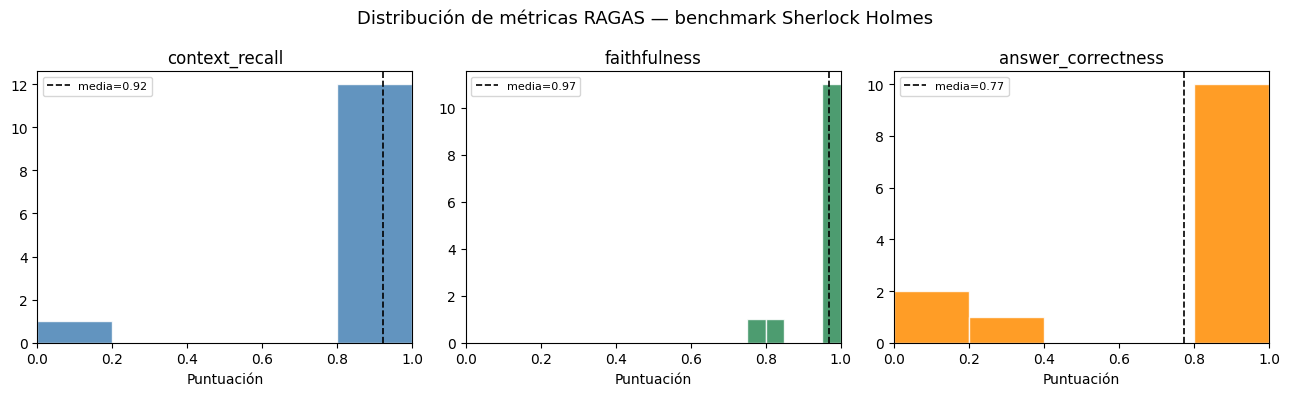

In [47]:
import matplotlib.pyplot as plt

metrics = ['context_recall', 'faithfulness', 'answer_correctness']
colors  = ['steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Distribución de métricas RAGAS — benchmark Sherlock Holmes', fontsize=13)

for ax, metric, color in zip(axes, metrics, colors):
    ax.hist(scored_df[metric].dropna(), bins=5, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(scored_df[metric].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'media={scored_df[metric].mean():.2f}')
    ax.set_title(metric)
    ax.set_xlabel('Puntuación')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

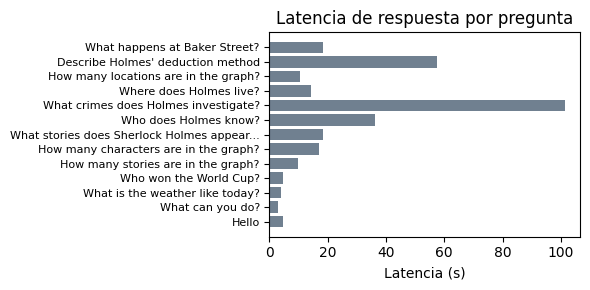

In [48]:
# Distribución de latencia
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(range(len(scored_df)), scored_df['latency'], color='slategray')
ax.set_yticks(range(len(scored_df)))
ax.set_yticklabels(
    [q[:40] + '...' if len(q) > 40 else q for q in scored_df['question']],
    fontsize=8
)
ax.set_xlabel('Latencia (s)')
ax.set_title('Latencia de respuesta por pregunta')
plt.tight_layout()
plt.show()

### 6.2 Mejor y peor caso por answer_correctness

Inspeccionar los extremos ayuda a diagnosticar *por qué* falla el sistema:
- `context_recall` bajo → el recuperador no encontró los chunks relevantes → ajustar `chunk_size` o `top_k`
- `faithfulness` bajo → el LLM alucinó → mejorar el prompt de respuesta o añadir instrucciones de anclaje
- `answer_correctness` bajo con `faithfulness` alto → el contexto recuperado era incompleto

In [49]:
def show_case(label, row):
    print(f"{'='*70}")
    print(label)
    print(f"{'='*70}")
    print(f"Question        : {row['question']}")
    print(f"Ground truth    : {str(row['ground_truth'])[:200]}")
    print(f"Answer          : {str(row['answer'])[:200]}")
    print(f"answer_correctness : {row['answer_correctness']:.3f}")
    print(f"context_recall     : {row['context_recall']:.3f}")
    print(f"faithfulness       : {row['faithfulness']:.3f}")
    print()

best_idx  = scored_df['answer_correctness'].idxmax()
worst_idx = scored_df['answer_correctness'].idxmin()

show_case("MEJOR CASO",  scored_df.loc[best_idx])
show_case("PEOR CASO", scored_df.loc[worst_idx])

MEJOR CASO
Question        : Hello
Ground truth    : Hello! I am a knowledge assistant specialising in Sherlock Holmes stories.
Answer          : ¡Hola! Soy un asistente de conocimiento especializado en las historias de Sherlock Holmes de Arthur Conan Doyle. Puedo responder preguntas sobre personajes, ubicaciones, crímenes, deducciones, objetos
answer_correctness : 1.000
context_recall     : 1.000
faithfulness       : 1.000

PEOR CASO
Question        : Where does Holmes live?
Ground truth    : 221B Baker Street, London
Answer          : Esta información no se encuentra en la base de conocimiento.
answer_correctness : 0.000
context_recall     : 0.000
faithfulness       : 1.000



### 6.3 Correlación entre métricas

¿Son las tres métricas independientes o tienden a moverse juntas?
Una correlación fuerte entre `context_recall` y `answer_correctness` confirmaría
que la calidad de la recuperación es el principal cuello de botella.

In [50]:
corr = scored_df[metrics].corr()
print("Correlación de Pearson entre métricas:")
print(corr.round(3))

Correlación de Pearson entre métricas:
                    context_recall  faithfulness  answer_correctness
context_recall               1.000        -0.120               0.582
faithfulness                -0.120         1.000               0.204
answer_correctness           0.582         0.204               1.000


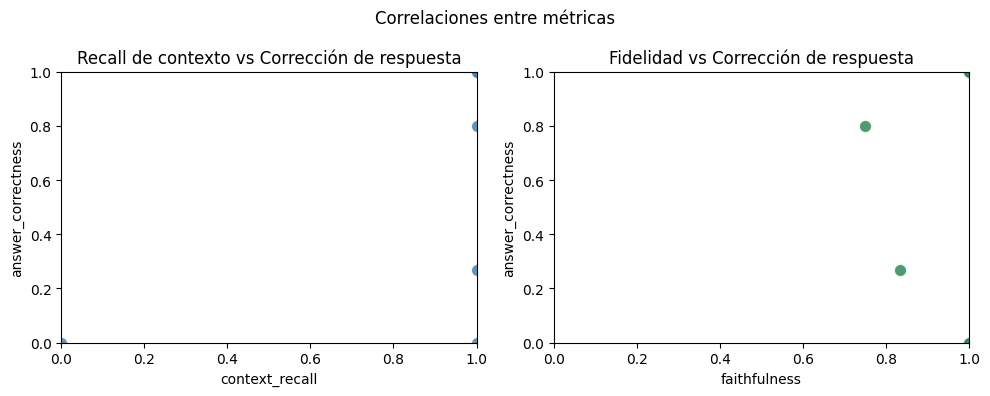

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(scored_df['context_recall'], scored_df['answer_correctness'],
                color='steelblue', edgecolors='white', s=80, alpha=0.85)
axes[0].set_xlabel('context_recall')
axes[0].set_ylabel('answer_correctness')
axes[0].set_title('Recall de contexto vs Corrección de respuesta')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

axes[1].scatter(scored_df['faithfulness'], scored_df['answer_correctness'],
                color='seagreen', edgecolors='white', s=80, alpha=0.85)
axes[1].set_xlabel('faithfulness')
axes[1].set_ylabel('answer_correctness')
axes[1].set_title('Fidelidad vs Corrección de respuesta')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.suptitle('Correlaciones entre métricas', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Guardar resultados

In [52]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = f"../data/evaluation_results_{timestamp}.csv"
scored_df.to_csv(out_path, index=False)
print(f"Resultados guardados en {out_path}")

Resultados guardados en ../data/evaluation_results_20260510_145208.csv


In [53]:
neo4j.close()